In [61]:
from sklearn import svm
from modulos.data_load import load, column_normalizer
from sklearn.preprocessing import StandardScaler
from argparse import Namespace
from modulos.typings import SVRNamespace
from matplotlib import pyplot as plt
import pandas as pd
import logging

In [62]:
args = SVRNamespace(crypto='ETCETH', model='SVR', excel='TEST.xlsx', figure='TEST.png', svr_kernel='poly', svr_degree=1)
args

SVCNamespace(crypto='ETCETH', model='SVR', figure='TEST.png', excel='TEST.xlsx', svc_kernel='poly', svc_degree=1)

In [63]:
logging.info(f"Running {args.model} on {args.crypto} crypto")
df = load(args.crypto)
df = column_normalizer(df)
df

,unix,date,symbol,open,high,low,close,Volume 1,Volume 2,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage
78354,1469332800000,2016-07-24 04:00:00,ETC/ETH,0.500000,0.50000,0.010000,0.039890,76.463213,1662.101035,0.00000,0.000,0,0.00000
78353,1469336400000,2016-07-24 05:00:00,ETC/ETH,0.039890,0.08880,0.010100,0.020000,273.776581,9617.213953,0.00000,0.000,0,0.00000
78352,1469340000000,2016-07-24 06:00:00,ETC/ETH,0.033300,0.08300,0.025005,0.066600,449.015823,8481.846660,0.00000,0.000,0,0.00000
78351,1469343600000,2016-07-24 07:00:00,ETC/ETH,0.066600,0.14500,0.058200,0.088820,2399.445217,22586.706448,0.00000,0.000,0,0.00000
78350,1469347200000,2016-07-24 08:00:00,ETC/ETH,0.088801,0.09990,0.041000,0.074275,859.065290,10985.270095,0.00000,0.000,0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,ETC/ETH,0.006620,0.00676,0.006600,0.006610,0.143500,21.655000,0.09627,14.527,22,0.00662
3,1751403600000,2025-07-01 21:00:00,ETC/ETH,0.006610,0.00665,0.006580,0.006650,0.009550,1.449000,0.00099,0.149,7,0.00659
2,1751407200000,2025-07-01 22:00:00,ETC/ETH,0.006600,0.00667,0.006570,0.006630,0.162660,24.602000,0.10056,15.177,44,0.00661
1,1751410800000,2025-07-01 23:00:00,ETC/ETH,0.006650,0.00667,0.006490,0.006490,0.076250,11.506000,0.02814,4.259,14,0.00662


In [64]:
X = StandardScaler().fit_transform(df[['unix', 'weightedAverage']])
X

array([[-1.7320049 , -0.63451083],
       [-1.73196069, -0.63451083],
       [-1.73191648, -0.63451083],
       ...,
       [ 1.73197182,  0.59359772],
       [ 1.73201603,  0.59545567],
       [ 1.73206023,  0.59359772]], shape=(78355, 2))

In [65]:
y = df['close']
y

78354    0.039890
78353    0.020000
78352    0.066600
78351    0.088820
78350    0.074275
           ...   
4        0.006610
3        0.006650
2        0.006630
1        0.006490
0        0.006650
Name: close, Length: 78355, dtype: float64

In [66]:
regr = svm.SVR(kernel=args.svr_kernel, degree=args.svr_degree)
regr.fit(X, y)

,kernel,'poly'
,degree,1
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [67]:
regr.predict(X)

array([ 0.16125007,  0.16124647,  0.16124288, ..., -0.09338772,
       -0.09335067, -0.0933949 ], shape=(78355,))

In [68]:
df

,unix,date,symbol,open,high,low,close,Volume 1,Volume 2,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage
78354,1469332800000,2016-07-24 04:00:00,ETC/ETH,0.500000,0.50000,0.010000,0.039890,76.463213,1662.101035,0.00000,0.000,0,0.00000
78353,1469336400000,2016-07-24 05:00:00,ETC/ETH,0.039890,0.08880,0.010100,0.020000,273.776581,9617.213953,0.00000,0.000,0,0.00000
78352,1469340000000,2016-07-24 06:00:00,ETC/ETH,0.033300,0.08300,0.025005,0.066600,449.015823,8481.846660,0.00000,0.000,0,0.00000
78351,1469343600000,2016-07-24 07:00:00,ETC/ETH,0.066600,0.14500,0.058200,0.088820,2399.445217,22586.706448,0.00000,0.000,0,0.00000
78350,1469347200000,2016-07-24 08:00:00,ETC/ETH,0.088801,0.09990,0.041000,0.074275,859.065290,10985.270095,0.00000,0.000,0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,ETC/ETH,0.006620,0.00676,0.006600,0.006610,0.143500,21.655000,0.09627,14.527,22,0.00662
3,1751403600000,2025-07-01 21:00:00,ETC/ETH,0.006610,0.00665,0.006580,0.006650,0.009550,1.449000,0.00099,0.149,7,0.00659
2,1751407200000,2025-07-01 22:00:00,ETC/ETH,0.006600,0.00667,0.006570,0.006630,0.162660,24.602000,0.10056,15.177,44,0.00661
1,1751410800000,2025-07-01 23:00:00,ETC/ETH,0.006650,0.00667,0.006490,0.006490,0.076250,11.506000,0.02814,4.259,14,0.00662


In [69]:
columns = df.columns.copy().to_list()
columns.remove('close')
columns.append('close')
df = df[columns]
df

,unix,date,symbol,open,high,low,Volume 1,Volume 2,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage,close
78354,1469332800000,2016-07-24 04:00:00,ETC/ETH,0.500000,0.50000,0.010000,76.463213,1662.101035,0.00000,0.000,0,0.00000,0.039890
78353,1469336400000,2016-07-24 05:00:00,ETC/ETH,0.039890,0.08880,0.010100,273.776581,9617.213953,0.00000,0.000,0,0.00000,0.020000
78352,1469340000000,2016-07-24 06:00:00,ETC/ETH,0.033300,0.08300,0.025005,449.015823,8481.846660,0.00000,0.000,0,0.00000,0.066600
78351,1469343600000,2016-07-24 07:00:00,ETC/ETH,0.066600,0.14500,0.058200,2399.445217,22586.706448,0.00000,0.000,0,0.00000,0.088820
78350,1469347200000,2016-07-24 08:00:00,ETC/ETH,0.088801,0.09990,0.041000,859.065290,10985.270095,0.00000,0.000,0,0.00000,0.074275
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,ETC/ETH,0.006620,0.00676,0.006600,0.143500,21.655000,0.09627,14.527,22,0.00662,0.006610
3,1751403600000,2025-07-01 21:00:00,ETC/ETH,0.006610,0.00665,0.006580,0.009550,1.449000,0.00099,0.149,7,0.00659,0.006650
2,1751407200000,2025-07-01 22:00:00,ETC/ETH,0.006600,0.00667,0.006570,0.162660,24.602000,0.10056,15.177,44,0.00661,0.006630
1,1751410800000,2025-07-01 23:00:00,ETC/ETH,0.006650,0.00667,0.006490,0.076250,11.506000,0.02814,4.259,14,0.00662,0.006490


In [70]:
df['PREDICTED'] = regr.predict(X)
df

/tmp/ipykernel_77256/1397791100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PREDICTED'] = regr.predict(X)


,unix,date,symbol,open,high,low,Volume 1,Volume 2,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage,close,PREDICTED
78354,1469332800000,2016-07-24 04:00:00,ETC/ETH,0.500000,0.50000,0.010000,76.463213,1662.101035,0.00000,0.000,0,0.00000,0.039890,0.161250
78353,1469336400000,2016-07-24 05:00:00,ETC/ETH,0.039890,0.08880,0.010100,273.776581,9617.213953,0.00000,0.000,0,0.00000,0.020000,0.161246
78352,1469340000000,2016-07-24 06:00:00,ETC/ETH,0.033300,0.08300,0.025005,449.015823,8481.846660,0.00000,0.000,0,0.00000,0.066600,0.161243
78351,1469343600000,2016-07-24 07:00:00,ETC/ETH,0.066600,0.14500,0.058200,2399.445217,22586.706448,0.00000,0.000,0,0.00000,0.088820,0.161239
78350,1469347200000,2016-07-24 08:00:00,ETC/ETH,0.088801,0.09990,0.041000,859.065290,10985.270095,0.00000,0.000,0,0.00000,0.074275,0.161236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,ETC/ETH,0.006620,0.00676,0.006600,0.143500,21.655000,0.09627,14.527,22,0.00662,0.006610,-0.093340
3,1751403600000,2025-07-01 21:00:00,ETC/ETH,0.006610,0.00665,0.006580,0.009550,1.449000,0.00099,0.149,7,0.00659,0.006650,-0.093465
2,1751407200000,2025-07-01 22:00:00,ETC/ETH,0.006600,0.00667,0.006570,0.162660,24.602000,0.10056,15.177,44,0.00661,0.006630,-0.093388
1,1751410800000,2025-07-01 23:00:00,ETC/ETH,0.006650,0.00667,0.006490,0.076250,11.506000,0.02814,4.259,14,0.00662,0.006490,-0.093351


In [71]:
# def p(row: pd.Series): abs(row['close'] - row['PREDICTED'])
# df[[ 'close', 'PREDICTED' ]].loc[1:1].apply(lambda row: abs(row['close'] - row['PREDICTED']), axis=1)

In [72]:
error = df[[ 'close', 'PREDICTED' ]].apply(lambda row: abs(row['close'] - row['PREDICTED']), axis=1)
error

78354    0.121360
78353    0.141246
78352    0.094643
78351    0.072419
78350    0.086961
           ...   
4        0.099950
3        0.100115
2        0.100018
1        0.099841
0        0.100045
Length: 78355, dtype: float64

In [73]:
df.loc[error.index, 'ERROR'] = error
df

/tmp/ipykernel_77256/1860503649.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[error.index, 'ERROR'] = error


,unix,date,symbol,open,high,low,Volume 1,Volume 2,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage,close,PREDICTED,ERROR
78354,1469332800000,2016-07-24 04:00:00,ETC/ETH,0.500000,0.50000,0.010000,76.463213,1662.101035,0.00000,0.000,0,0.00000,0.039890,0.161250,0.121360
78353,1469336400000,2016-07-24 05:00:00,ETC/ETH,0.039890,0.08880,0.010100,273.776581,9617.213953,0.00000,0.000,0,0.00000,0.020000,0.161246,0.141246
78352,1469340000000,2016-07-24 06:00:00,ETC/ETH,0.033300,0.08300,0.025005,449.015823,8481.846660,0.00000,0.000,0,0.00000,0.066600,0.161243,0.094643
78351,1469343600000,2016-07-24 07:00:00,ETC/ETH,0.066600,0.14500,0.058200,2399.445217,22586.706448,0.00000,0.000,0,0.00000,0.088820,0.161239,0.072419
78350,1469347200000,2016-07-24 08:00:00,ETC/ETH,0.088801,0.09990,0.041000,859.065290,10985.270095,0.00000,0.000,0,0.00000,0.074275,0.161236,0.086961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,ETC/ETH,0.006620,0.00676,0.006600,0.143500,21.655000,0.09627,14.527,22,0.00662,0.006610,-0.093340,0.099950
3,1751403600000,2025-07-01 21:00:00,ETC/ETH,0.006610,0.00665,0.006580,0.009550,1.449000,0.00099,0.149,7,0.00659,0.006650,-0.093465,0.100115
2,1751407200000,2025-07-01 22:00:00,ETC/ETH,0.006600,0.00667,0.006570,0.162660,24.602000,0.10056,15.177,44,0.00661,0.006630,-0.093388,0.100018
1,1751410800000,2025-07-01 23:00:00,ETC/ETH,0.006650,0.00667,0.006490,0.076250,11.506000,0.02814,4.259,14,0.00662,0.006490,-0.093351,0.099841


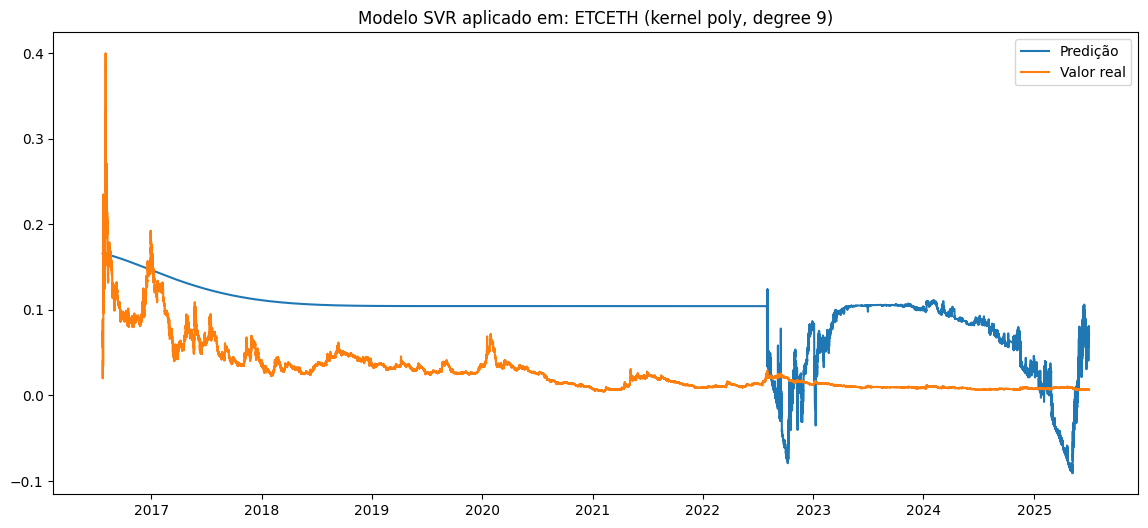

In [60]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['PREDICTED'], label='Predição')
plt.plot(df['date'], df['close'], label='Valor real')
plt.title(f"Modelo {args.model} aplicado em: {args.crypto} (kernel {args.svr_kernel}{
    f', degree {args.svr_degree}' if args.svr_kernel == 'poly' else ''
})")
plt.legend()

In [16]:
plt.savefig(args.figure)

<Figure size 640x480 with 0 Axes>

In [18]:
if args.excel is not None:
    df.to_excel(args.excel, sheet_name=f"Modelo {args.model} aplicado em {args.crypto} (kernel {args.svr_kernel}{
        f', degree {args.svr_degree}' if args.svr_kernel == 'poly' else ''
    })")

/home/higor/anaconda3/envs/trabalho_final/lib/python3.12/site-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
